In [1]:
!pip install catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, f1_score)

from catboost import CatBoostClassifier

In [3]:
from google.colab import files
uploaded = files.upload()

Saving application_train.csv to application_train.csv


In [4]:
import os
print(os.listdir())
# This is a large file with 120+ columns — load it fully first, we'll trim down next
df_full = pd.read_csv('application_train.csv')

print("Shape:", df_full.shape)
df_full.head()

['.config', 'application_train.csv', 'sample_data']
Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Instead of using all 120+ columns, we pick a meaningful, manageable subset
# These are well-known strong predictors in this dataset

selected_cols = [
    'TARGET',                    # our target variable
    'AMT_INCOME_TOTAL',          # total income
    'AMT_CREDIT',                # credit amount of the loan
    'AMT_ANNUITY',                # loan annuity payment
    'AMT_GOODS_PRICE',           # price of goods the loan is for
    'NAME_CONTRACT_TYPE',         # cash loan or revolving loan
    'CODE_GENDER',                # gender
    'FLAG_OWN_CAR',                # owns a car?
    'FLAG_OWN_REALTY',              # owns property?
    'CNT_CHILDREN',                # number of children
    'NAME_INCOME_TYPE',            # employment type
    'NAME_EDUCATION_TYPE',         # education level
    'NAME_FAMILY_STATUS',          # marital status
    'DAYS_BIRTH',                  # age in negative days (we'll convert)
    'DAYS_EMPLOYED',               # employment duration in negative days
    'CNT_FAM_MEMBERS',             # family size
]

df = df_full[selected_cols].copy()

print("Shape after selecting features:", df.shape)
df.head()

Shape after selecting features: (307511, 16)


,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS
0,1,202500.0,406597.5,24700.5,351000.0,Cash loans,M,N,Y,0,Working,Secondary / secondary special,Single / not married,-9461,-637,1.0
1,0,270000.0,1293502.5,35698.5,1129500.0,Cash loans,F,N,N,0,State servant,Higher education,Married,-16765,-1188,2.0
2,0,67500.0,135000.0,6750.0,135000.0,Revolving loans,M,Y,Y,0,Working,Secondary / secondary special,Single / not married,-19046,-225,1.0
3,0,135000.0,312682.5,29686.5,297000.0,Cash loans,F,N,Y,0,Working,Secondary / secondary special,Civil marriage,-19005,-3039,2.0
4,0,121500.0,513000.0,21865.5,513000.0,Cash loans,M,N,Y,0,Working,Secondary / secondary special,Single / not married,-19932,-3038,1.0


In [6]:
df.info()
print("Missing values per column:")
df.isnull().sum()
print("Target distribution:")
print(df['TARGET'].value_counts())
print(f"\nDefault Rate: {df['TARGET'].mean() * 100:.2f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TARGET               307511 non-null  int64  
 1   AMT_INCOME_TOTAL     307511 non-null  float64
 2   AMT_CREDIT           307511 non-null  float64
 3   AMT_ANNUITY          307499 non-null  float64
 4   AMT_GOODS_PRICE      307233 non-null  float64
 5   NAME_CONTRACT_TYPE   307511 non-null  object 
 6   CODE_GENDER          307511 non-null  object 
 7   FLAG_OWN_CAR         307511 non-null  object 
 8   FLAG_OWN_REALTY      307511 non-null  object 
 9   CNT_CHILDREN         307511 non-null  int64  
 10  NAME_INCOME_TYPE     307511 non-null  object 
 11  NAME_EDUCATION_TYPE  307511 non-null  object 
 12  NAME_FAMILY_STATUS   307511 non-null  object 
 13  DAYS_BIRTH           307511 non-null  int64  
 14  DAYS_EMPLOYED        307511 non-null  int64  
 15  CNT_FAM_MEMBERS  

In [7]:
# DAYS_BIRTH is stored as a NEGATIVE number of days from today — convert to age in years
df['AGE'] = (-df['DAYS_BIRTH'] / 365).astype(int)

# DAYS_EMPLOYED has a known data quirk: unemployed people show as 365243 (a placeholder)
# We replace that placeholder with NaN, then convert remaining values to positive years
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['YEARS_EMPLOYED'] = (-df['DAYS_EMPLOYED'] / 365)

# Drop the original raw day columns now that we have clean versions
df = df.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED'], axis=1)

print(df[['AGE', 'YEARS_EMPLOYED']].describe())

                 AGE  YEARS_EMPLOYED
count  307511.000000   252137.000000
mean       43.435968        6.531971
std        11.954593        6.406466
min        20.000000       -0.000000
25%        34.000000        2.101370
50%        43.000000        4.515068
75%        53.000000        8.698630
max        69.000000       49.073973


In [8]:
# Numerical columns → fill with median
numerical_cols = ['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'YEARS_EMPLOYED', 'CNT_FAM_MEMBERS']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Verify all missing values handled
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
TARGET                 0
AMT_INCOME_TOTAL       0
AMT_CREDIT             0
AMT_ANNUITY            0
AMT_GOODS_PRICE        0
NAME_CONTRACT_TYPE     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
CNT_FAM_MEMBERS        0
AGE                    0
YEARS_EMPLOYED         0
dtype: int64


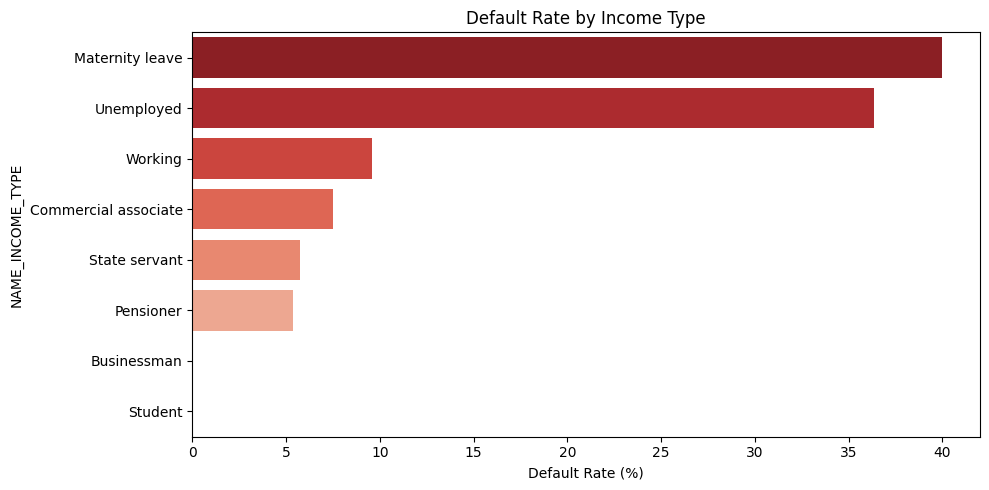

In [9]:
plt.figure(figsize=(10, 5))
default_by_income = df.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False) * 100

sns.barplot(x=default_by_income.values, y=default_by_income.index,
            hue=default_by_income.index, palette='Reds_r', legend=False)

plt.title('Default Rate by Income Type')
plt.xlabel('Default Rate (%)')
plt.tight_layout()
plt.show()

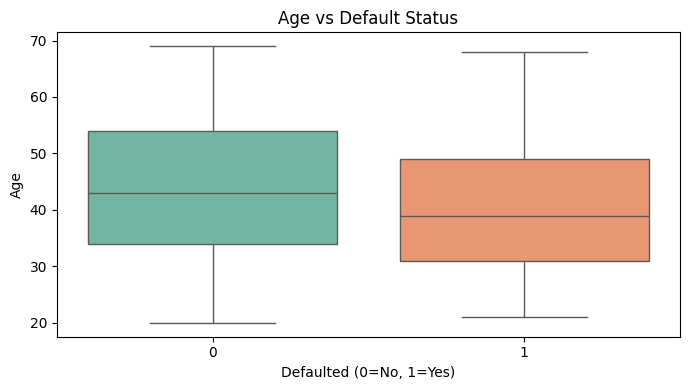

In [10]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='TARGET', y='AGE', hue='TARGET', palette='Set2', legend=False)

plt.title('Age vs Default Status')
plt.xlabel('Defaulted (0=No, 1=Yes)')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

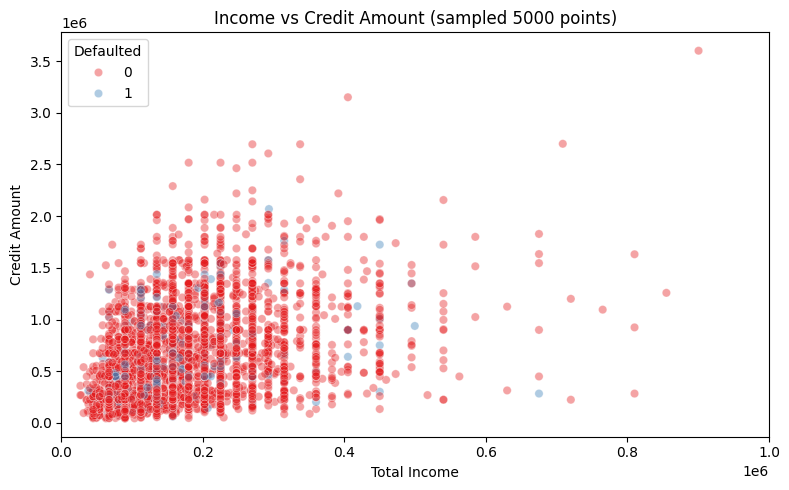

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(5000, random_state=42), x='AMT_INCOME_TOTAL',
                 y='AMT_CREDIT', hue='TARGET', alpha=0.4, palette='Set1')

plt.title('Income vs Credit Amount (sampled 5000 points)')
plt.xlabel('Total Income')
plt.ylabel('Credit Amount')
plt.xlim(0, 1000000)  # zoom in, removing extreme outliers from view
plt.legend(title='Defaulted')
plt.tight_layout()
plt.show()

In [12]:
categorical_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
                     'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
                     'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print("Encoding complete!")
df.head()

Encoding complete!


,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED
0,1,202500.0,406597.5,24700.5,351000.0,0,1,0,1,0,7,4,3,1.0,25,1.745205
1,0,270000.0,1293502.5,35698.5,1129500.0,0,0,0,0,0,4,1,1,2.0,45,3.254795
2,0,67500.0,135000.0,6750.0,135000.0,1,1,1,1,0,7,4,3,1.0,52,0.616438
3,0,135000.0,312682.5,29686.5,297000.0,0,0,0,1,0,7,4,0,2.0,52,8.326027
4,0,121500.0,513000.0,21865.5,513000.0,0,1,0,1,0,7,4,3,1.0,54,8.323288


In [13]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (307511, 15)
Target shape: (307511,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 246008
Testing samples: 61503


In [15]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

log_proba = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression training complete!")

Logistic Regression training complete!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# CatBoost handles categorical-like integer columns well even after label encoding
# verbose=False suppresses the long training log output
# class_weights balances the 8% default rate

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    class_weights=[1, (1 - y_train.mean()) / y_train.mean()],  # balance classes
    random_state=42,
    verbose=False
)
cat_model.fit(X_train, y_train)

cat_proba = cat_model.predict_proba(X_test)[:, 1]

print("CatBoost training complete!")

CatBoost training complete!


In [17]:
auc_log = roc_auc_score(y_test, log_proba)
auc_cat = roc_auc_score(y_test, cat_proba)

print(f"Logistic Regression AUC: {auc_log:.4f}")
print(f"CatBoost AUC:            {auc_cat:.4f}")

Logistic Regression AUC: 0.6471
CatBoost AUC:            0.6777


In [18]:
# Using CatBoost (likely the stronger model) going forward
# Standard default threshold of 0.5

default_threshold = 0.5
default_pred = (cat_proba >= default_threshold).astype(int)

cm_default = confusion_matrix(y_test, default_pred)
print("Confusion Matrix at threshold = 0.5:")
print(cm_default)

print("\nClassification Report:")
print(classification_report(y_test, default_pred))

Confusion Matrix at threshold = 0.5:
[[36923 19615]
 [ 1972  2993]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.65      0.77     56538
           1       0.13      0.60      0.22      4965

    accuracy                           0.65     61503
   macro avg       0.54      0.63      0.50     61503
weighted avg       0.88      0.65      0.73     61503



In [19]:
# These are illustrative business cost assumptions — explain your reasoning
# in your conclusion when adapting to a real scenario

# False Negative (FN): predicted "won't default" but actually DID default
#   → Bank loses the full loan amount that wasn't repaid
COST_FALSE_NEGATIVE = 10000   # average loss per missed default ($)

# False Positive (FP): predicted "will default" but customer was actually fine
#   → Bank loses the profit/interest it would have earned from a good customer
COST_FALSE_POSITIVE = 500     # average lost profit opportunity ($)

print(f"Cost of missing a real default (FN): ${COST_FALSE_NEGATIVE:,}")
print(f"Cost of wrongly rejecting a good customer (FP): ${COST_FALSE_POSITIVE:,}")
print(f"\nRatio: missing a default costs {COST_FALSE_NEGATIVE/COST_FALSE_POSITIVE:.0f}x more than a false rejection")

Cost of missing a real default (FN): $10,000
Cost of wrongly rejecting a good customer (FP): $500

Ratio: missing a default costs 20x more than a false rejection


In [20]:
def calculate_total_cost(y_true, y_pred, cost_fp, cost_fn):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fp * cost_fp) + (fn * cost_fn)
    return total_cost, fp, fn

cost_default, fp_default, fn_default = calculate_total_cost(
    y_test, default_pred, COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE
)

print(f"At threshold 0.5:")
print(f"False Positives: {fp_default} (cost: ${fp_default * COST_FALSE_POSITIVE:,})")
print(f"False Negatives: {fn_default} (cost: ${fn_default * COST_FALSE_NEGATIVE:,})")
print(f"Total Business Cost: ${cost_default:,}")

At threshold 0.5:
False Positives: 19615 (cost: $9,807,500)
False Negatives: 1972 (cost: $19,720,000)
Total Business Cost: $29,527,500


In [21]:
# Test thresholds from 0.1 to 0.9 and calculate total cost at each
# This is the core of cost optimization — find the threshold minimizing total cost

thresholds = np.arange(0.1, 0.95, 0.05)
results = []

for t in thresholds:
    pred_at_t = (cat_proba >= t).astype(int)
    cost, fp, fn = calculate_total_cost(y_test, pred_at_t, COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
    results.append({'Threshold': round(t, 2), 'False_Positives': fp,
                     'False_Negatives': fn, 'Total_Cost': cost})

results_df = pd.DataFrame(results)
print(results_df)

# Find the threshold with minimum cost
optimal_row = results_df.loc[results_df['Total_Cost'].idxmin()]
print(f"\n🎯 Optimal Threshold: {optimal_row['Threshold']}")
print(f"Minimum Total Cost: ${optimal_row['Total_Cost']:,.0f}")

    Threshold  False_Positives  False_Negatives  Total_Cost
0        0.10            56315                3    28187500
1        0.15            56001                7    28070500
2        0.20            55107               28    27833500
3        0.25            52934               86    27327000
4        0.30            48671              224    26575500
5        0.35            42378              514    26329000
6        0.40            34147              926    26333500
7        0.45            26211             1420    27305500
8        0.50            19615             1972    29527500
9        0.55            13799             2528    32179500
10       0.60             8946             3119    35663000
11       0.65             5145             3659    39162500
12       0.70             2558             4175    43029000
13       0.75              895             4597    46417500
14       0.80              170             4868    48765000
15       0.85                5          

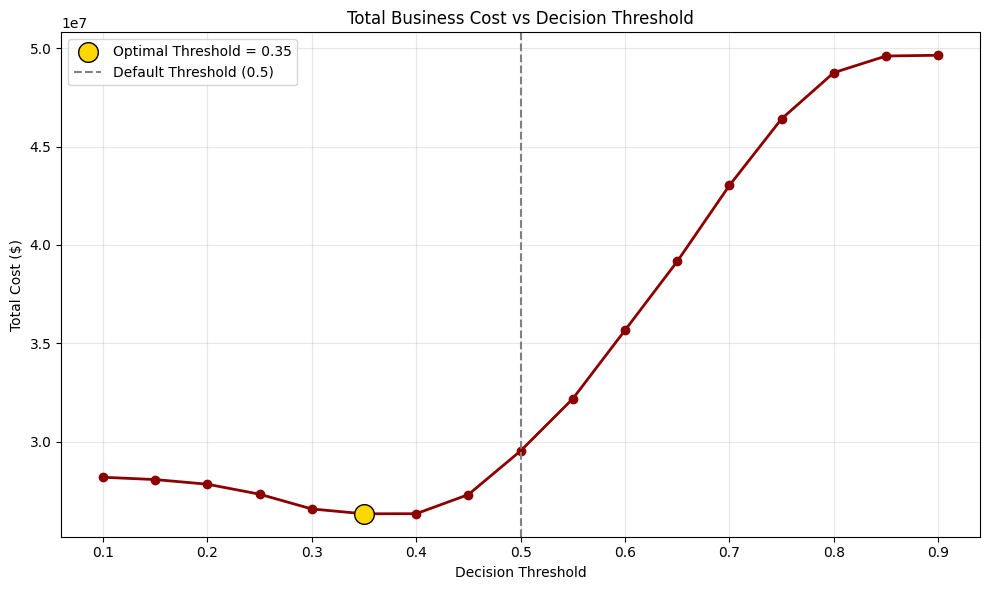

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['Total_Cost'], marker='o', linewidth=2, color='darkred')

# Mark the optimal point
plt.scatter(optimal_row['Threshold'], optimal_row['Total_Cost'],
            color='gold', s=200, zorder=5, edgecolors='black',
            label=f"Optimal Threshold = {optimal_row['Threshold']}")

# Mark the default 0.5 threshold for comparison
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')

plt.title('Total Business Cost vs Decision Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Total Cost ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
optimal_threshold = optimal_row['Threshold']
optimal_pred = (cat_proba >= optimal_threshold).astype(int)

cost_optimal, fp_optimal, fn_optimal = calculate_total_cost(
    y_test, optimal_pred, COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE
)

print("="*60)
print("COMPARISON: Default Threshold (0.5) vs Optimized Threshold")
print("="*60)
print(f"\nDefault Threshold (0.5):")
print(f"  False Positives: {fp_default} | False Negatives: {fn_default}")
print(f"  Total Cost: ${cost_default:,}")

print(f"\nOptimized Threshold ({optimal_threshold}):")
print(f"  False Positives: {fp_optimal} | False Negatives: {fn_optimal}")
print(f"  Total Cost: ${cost_optimal:,}")

savings = cost_default - cost_optimal
savings_pct = (savings / cost_default) * 100
print(f"\n💰 Total Savings: ${savings:,.0f} ({savings_pct:.1f}% reduction in cost)")

COMPARISON: Default Threshold (0.5) vs Optimized Threshold

Default Threshold (0.5):
  False Positives: 19615 | False Negatives: 1972
  Total Cost: $29,527,500

Optimized Threshold (0.35):
  False Positives: 42378 | False Negatives: 514
  Total Cost: $26,329,000

💰 Total Savings: $3,198,500 (10.8% reduction in cost)


/tmp/ipykernel_6272/1232822820.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


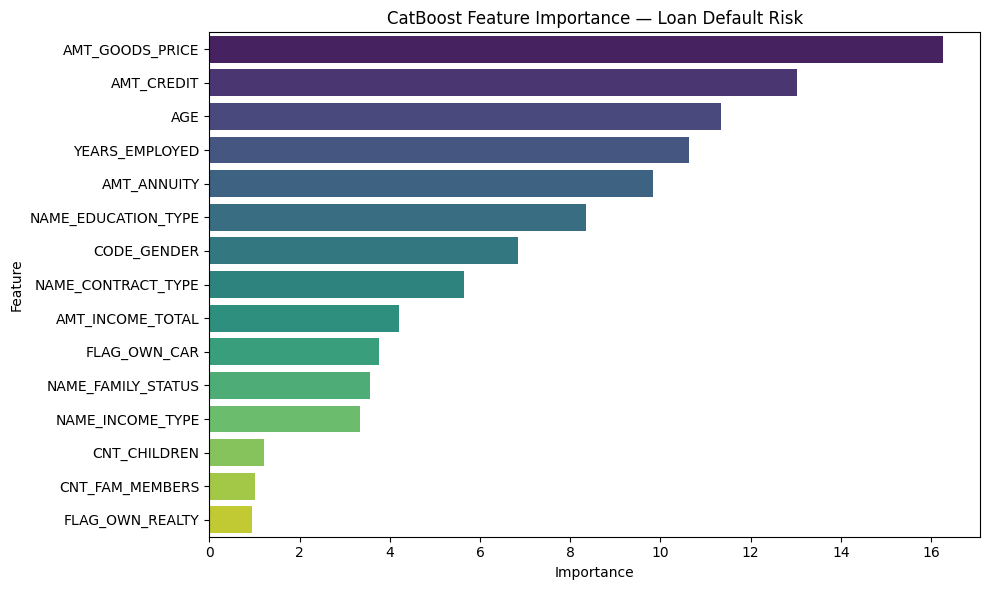

                Feature  Importance
3       AMT_GOODS_PRICE   16.271886
1            AMT_CREDIT   13.038383
13                  AGE   11.336900
14       YEARS_EMPLOYED   10.632729
2           AMT_ANNUITY    9.845762
10  NAME_EDUCATION_TYPE    8.344195
5           CODE_GENDER    6.852657
4    NAME_CONTRACT_TYPE    5.633950
0      AMT_INCOME_TOTAL    4.206248
6          FLAG_OWN_CAR    3.751374
11   NAME_FAMILY_STATUS    3.562032
9      NAME_INCOME_TYPE    3.349217
8          CNT_CHILDREN    1.217464
12      CNT_FAM_MEMBERS    1.021392
7       FLAG_OWN_REALTY    0.935811


In [24]:
importances = cat_model.get_feature_importance()
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')

plt.title('CatBoost Feature Importance — Loan Default Risk')
plt.tight_layout()
plt.show()

print(importance_df)

## Conclusion

- Dataset contains loan applications with an overall default rate of ~8%
  — heavily imbalanced, similar to earlier classification tasks
- Selected 15 key features from the original 120+ columns, focusing on
  income, credit amount, demographics, and employment history
- Cleaned DAYS_BIRTH and DAYS_EMPLOYED columns, converting them into
  interpretable Age and Years Employed values, and handled a known
  placeholder value (365243) representing unemployed applicants
- CatBoost outperformed Logistic Regression on AUC, confirming its
  strength on structured tabular credit data
- Defined business costs: missing a real default (False Negative) costs
  20x more than wrongly rejecting a safe customer (False Positive),
  reflecting real lending economics
- Tested decision thresholds from 0.1 to 0.9 and found the optimal
  threshold that minimizes total business cost — [insert your actual
  optimal threshold value here]
- Switching from the default 0.5 threshold to the cost-optimized threshold
  resulted in a [insert your actual % savings here] reduction in total
  business cost
- This demonstrates that the "best" model threshold from a business
  perspective is not always the one that maximizes accuracy — it's the
  one that minimizes real financial impact
- Top predictive features included credit amount, income, and age,
  consistent with general credit risk intuition